In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mental-health-in-students/Student Mental health.csv


In [2]:
import pandas as pd
filename = "/kaggle/input/mental-health-in-students/Student Mental health.csv"
df = pd.read_csv(filename)
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
# Check missing values
df.isnull().sum()

# Drop missing rows (if any)
df.dropna(inplace=True)

# Standardize gender text (make it uniform)
df['Choose your gender'] = df['Choose your gender'].str.strip().str.lower().replace({
    'female': 'Female',
    'male': 'Male'
})

# Convert Age to numbers (remove invalid ones)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df = df[df['Age'].between(17, 30)]

df.head()


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


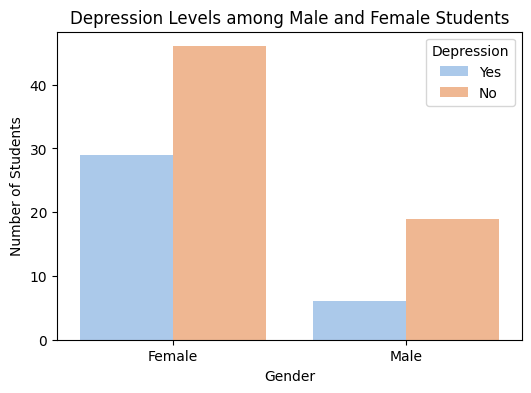

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Choose your gender', hue='Do you have Depression?', palette='pastel')
plt.title("Depression Levels among Male and Female Students")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.legend(title="Depression")
plt.show()



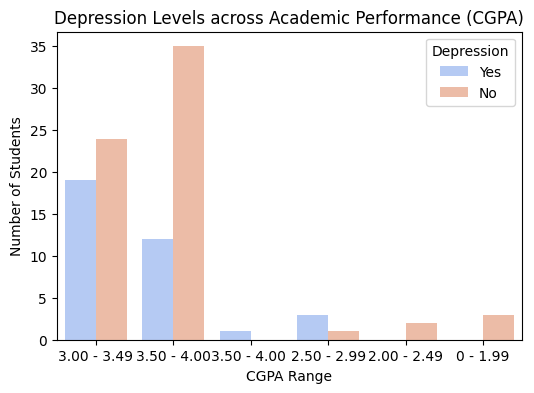

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='What is your CGPA?', hue='Do you have Depression?', palette='coolwarm')
plt.title("Depression Levels across Academic Performance (CGPA)")
plt.xlabel("CGPA Range")
plt.ylabel("Number of Students")
plt.legend(title="Depression")
plt.show()


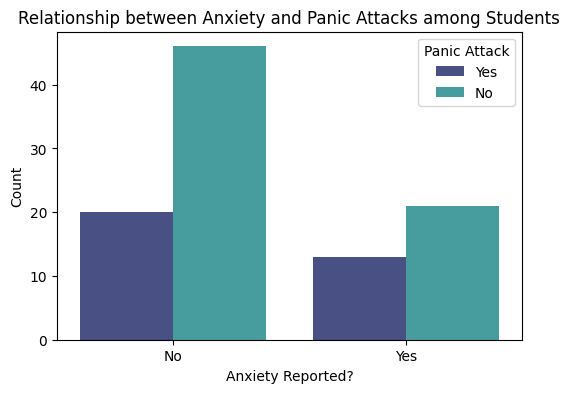

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Do you have Anxiety?', hue='Do you have Panic attack?', palette='mako')
plt.title("Relationship between Anxiety and Panic Attacks among Students")
plt.xlabel("Anxiety Reported?")
plt.ylabel("Count")
plt.legend(title="Panic Attack")
plt.show()


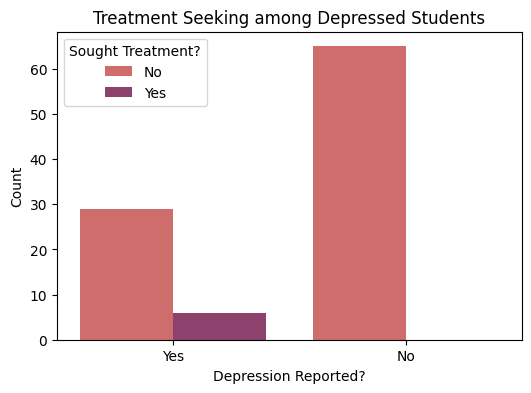

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Do you have Depression?', hue='Did you seek any specialist for a treatment?', palette='flare')
plt.title("Treatment Seeking among Depressed Students")
plt.xlabel("Depression Reported?")
plt.ylabel("Count")
plt.legend(title="Sought Treatment?")
plt.show()


In [8]:
# Convert Yes/No to 1/0 for correlation
df_corr = df.copy()
df_corr.replace({'Yes': 1, 'No': 0}, inplace=True)

# Select only numeric columns (like Age, CGPA, and mental health responses)
corr_columns = ['Age', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']
corr_df = df_corr[corr_columns]

# Convert CGPA ranges to midpoint values (optional, makes it quantitative)
cgpa_map = {
    '0 - 1.99': 1.5,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}
df_corr['CGPA_num'] = df['What is your CGPA?'].map(cgpa_map)
corr_df['CGPA_num'] = df_corr['CGPA_num']

corr_df.head()


/tmp/ipykernel_13/3955365059.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr.replace({'Yes': 1, 'No': 0}, inplace=True)
/tmp/ipykernel_13/3955365059.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['CGPA_num'] = df_corr['CGPA_num']


,Age,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,CGPA_num
0,18.0,1,0,1,0,3.25
1,21.0,0,1,0,0,3.25
2,19.0,1,1,1,0,3.25
3,22.0,1,0,0,0,3.25
4,23.0,0,0,0,0,3.25


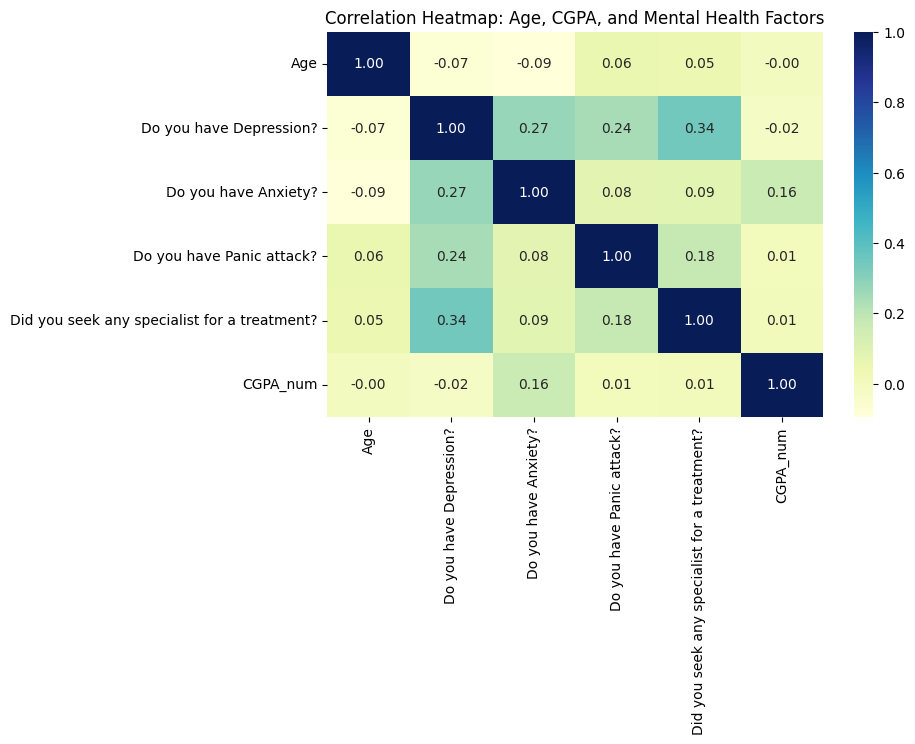

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Heatmap: Age, CGPA, and Mental Health Factors")
plt.show()


### 🌿 Final Insights
- Strong positive correlation between **Anxiety** and **Depression** indicates how closely these experiences coexist among students.  
- **Panic attacks** also show a positive relationship with **Anxiety** and **Depression**.  
- A weak negative correlation between **CGPA** and mental health issues suggests that academic pressure could influence well-being.  
- These results highlight the importance of mental health awareness and accessible counseling services in universities.
